# **1. Perkenalan Dataset**


Dataset **Telco Customer Churn** berisi informasi tentang pelanggan perusahaan telekomunikasi fiktif dan apakah mereka berhenti berlangganan (*churn*) dalam sebulan terakhir.

### Konteks
Setiap baris mewakili satu pelanggan, dan setiap kolom berisi atribut pelanggan tersebut. Dataset ini umumnya digunakan untuk memprediksi apakah seorang pelanggan akan *churn* atau tidak.

### Fitur Utama
| Kolom | Tipe | Deskripsi |
|---|---|---|
| `customerID` | object | ID unik pelanggan |
| `gender` | object | Jenis kelamin (Male/Female) |
| `SeniorCitizen` | int | Apakah pelanggan adalah warga senior (1/0) |
| `Partner` | object | Apakah pelanggan memiliki pasangan (Yes/No) |
| `Dependents` | object | Apakah pelanggan memiliki tanggungan (Yes/No) |
| `tenure` | int | Jumlah bulan pelanggan sudah berlangganan |
| `PhoneService` | object | Apakah pelanggan memiliki layanan telepon |
| `MultipleLines` | object | Apakah pelanggan memiliki beberapa jalur telepon |
| `InternetService` | object | Jenis layanan internet (DSL/Fiber optic/No) |
| `OnlineSecurity` | object | Apakah pelanggan memiliki keamanan online |
| `OnlineBackup` | object | Apakah pelanggan memiliki cadangan online |
| `DeviceProtection` | object | Apakah pelanggan memiliki perlindungan perangkat |
| `TechSupport` | object | Apakah pelanggan memiliki dukungan teknis |
| `StreamingTV` | object | Apakah pelanggan memiliki streaming TV |
| `StreamingMovies` | object | Apakah pelanggan memiliki streaming film |
| `Contract` | object | Jenis kontrak (Month-to-month/One year/Two year) |
| `PaperlessBilling` | object | Apakah pelanggan menggunakan tagihan tanpa kertas |
| `PaymentMethod` | object | Metode pembayaran |
| `MonthlyCharges` | float | Jumlah tagihan bulanan |
| `TotalCharges` | object | Total tagihan keseluruhan |
| `Churn` | object | **Target** - Apakah pelanggan churn (Yes/No) |

### Tujuan
Membangun model klasifikasi yang dapat memprediksi **apakah seorang pelanggan akan churn** berdasarkan fitur-fitur di atas.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [3]:
# ============================================================
# 2. Import Library
# ============================================================

# Library dasar
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Library visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Library preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer

# Library evaluasi (opsional, untuk eksplorasi awal)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Konfigurasi tampilan
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('✅ Semua library berhasil diimport!')

✅ Semua library berhasil diimport!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [4]:
# ============================================================
# 3. Memuat Dataset
# Sumber: https://raw.githubusercontent.com/dsrscientist/dataset1/master/telecom_churn.csv
# (mirror publik dari dataset Telco Customer Churn Kaggle)
# ============================================================

# URL dataset (mirror publik)
URL = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'

# Load dataset
df = pd.read_csv(URL)
print(f'✅ Dataset berhasil dimuat!')
print(f'   Ukuran dataset: {df.shape[0]} baris x {df.shape[1]} kolom')

✅ Dataset berhasil dimuat!
   Ukuran dataset: 7043 baris x 21 kolom


In [5]:
# Simpan raw dataset
df.to_csv('telcocustomerchurn_raw.csv', index=False)
print('✅ Dataset raw disimpan sebagai telcocustomerchurn_raw.csv')

✅ Dataset raw disimpan sebagai telcocustomerchurn_raw.csv


In [6]:
# Tampilkan 5 baris pertama
print('=== 5 Baris Pertama Dataset ===')
df.head()

=== 5 Baris Pertama Dataset ===


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
# Tampilkan 5 baris terakhir
print('=== 5 Baris Terakhir Dataset ===')
df.tail()

=== 5 Baris Terakhir Dataset ===


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [8]:
# Informasi umum dataset
print('=== Informasi Dataset ===')
df.info()

=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling

In [9]:
# Statistik deskriptif
print('=== Statistik Deskriptif ===')
df.describe(include='all')

=== Statistik Deskriptif ===


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [10]:
# ============================================================
# 4.1 Cek Missing Values
# ============================================================
print('=== Missing Values per Kolom ===')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0])

# Cek kolom TotalCharges - kemungkinan ada nilai kosong berupa string ' '
print(f'\nNilai unik TotalCharges yang kosong/spasi: {df["TotalCharges"].str.strip().eq("").sum()}')

=== Missing Values per Kolom ===
Empty DataFrame
Columns: [Missing Count, Missing (%)]
Index: []

Nilai unik TotalCharges yang kosong/spasi: 11


=== Distribusi Churn ===
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Persentase Churn:
Churn
No     73.46%
Yes    26.54%
Name: proportion, dtype: object


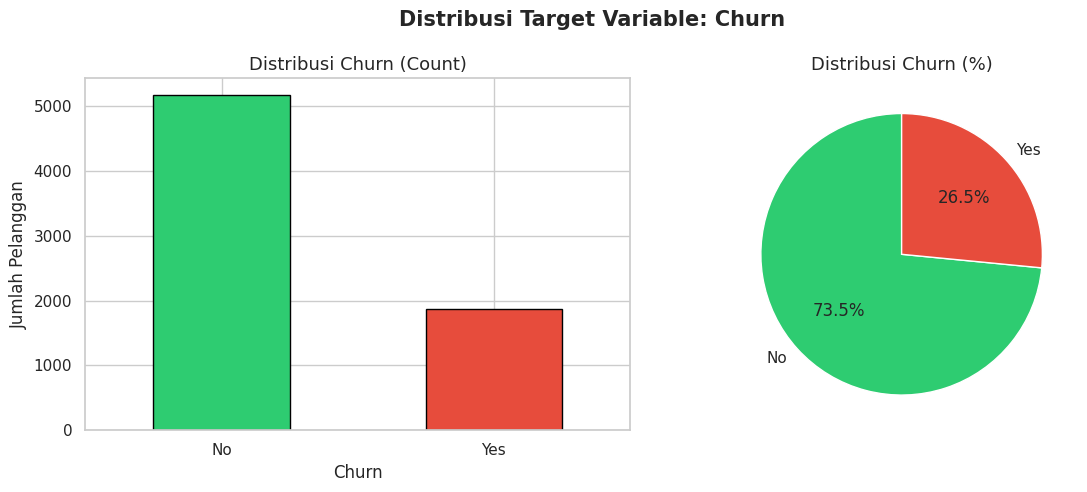

In [12]:
# ============================================================
# 4.2 Distribusi Target Variable
# ============================================================
print('=== Distribusi Churn ===')
print(df['Churn'].value_counts())
print(f'\nPersentase Churn:')
print(df['Churn'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
df['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Distribusi Churn (Count)', fontsize=13)
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Jumlah Pelanggan')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
df['Churn'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                 colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Distribusi Churn (%)', fontsize=13)
axes[1].set_ylabel('')

plt.suptitle('Distribusi Target Variable: Churn', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

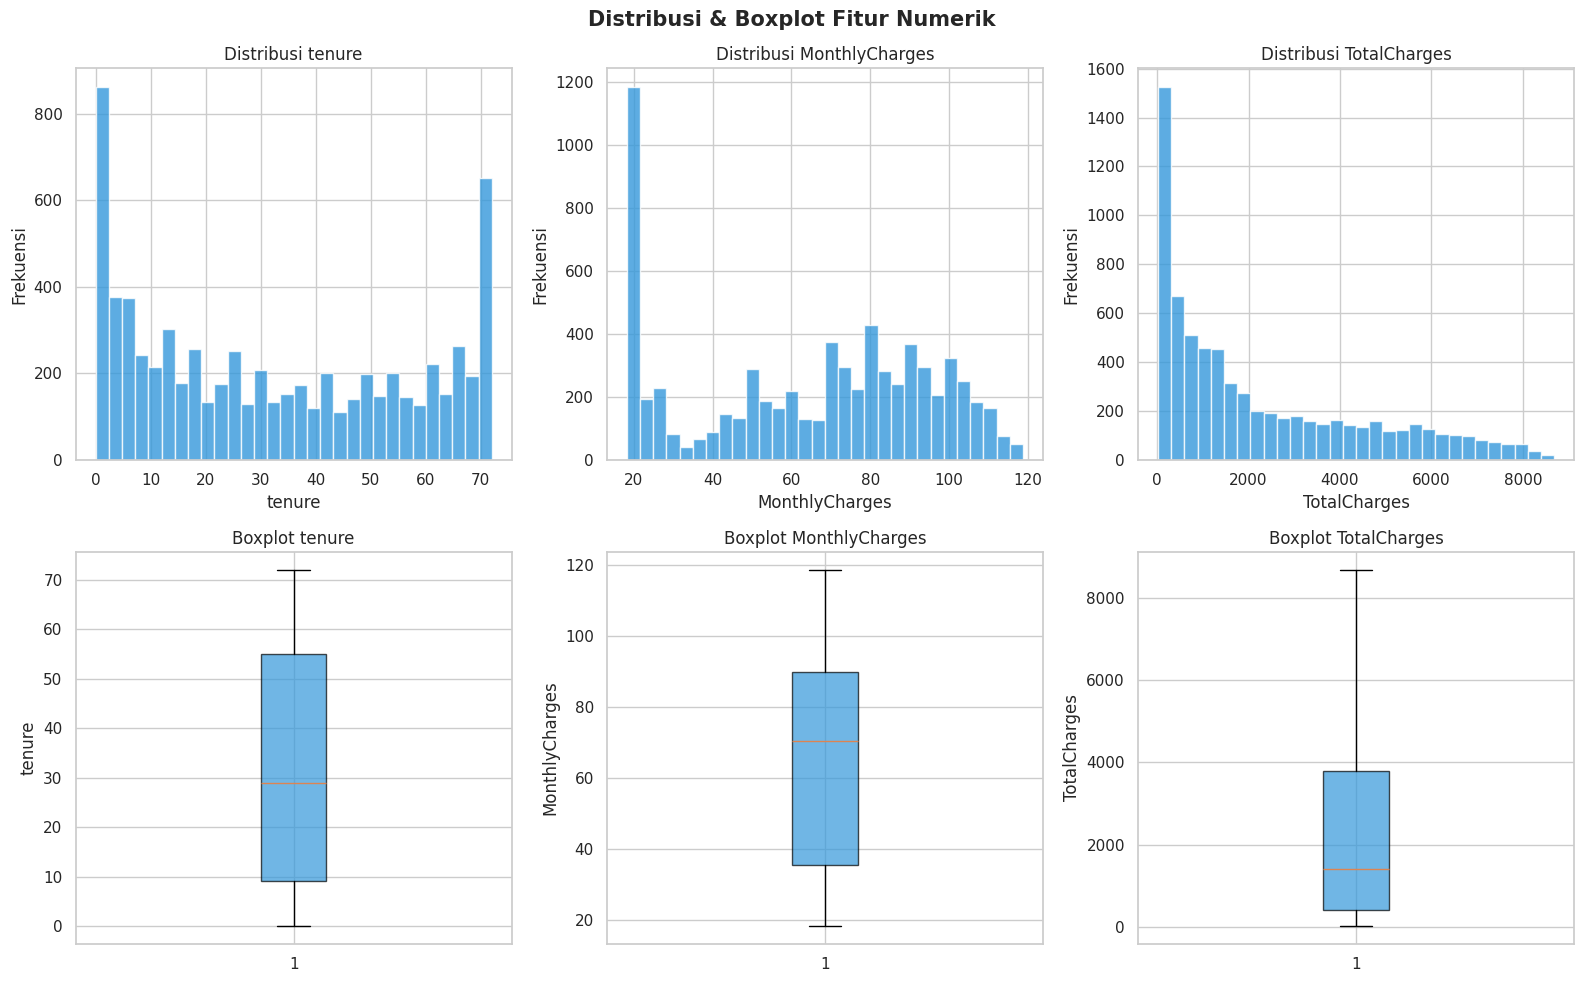

In [13]:
# ============================================================
# 4.3 Distribusi Fitur Numerik
# ============================================================
# Konversi TotalCharges ke numerik terlebih dahulu
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for i, col in enumerate(num_cols):
    # Histogram
    axes[0, i].hist(df[col].dropna(), bins=30, color='#3498db', edgecolor='white', alpha=0.8)
    axes[0, i].set_title(f'Distribusi {col}', fontsize=12)
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Frekuensi')

    # Boxplot
    axes[1, i].boxplot(df[col].dropna(), patch_artist=True,
                       boxprops=dict(facecolor='#3498db', alpha=0.7))
    axes[1, i].set_title(f'Boxplot {col}', fontsize=12)
    axes[1, i].set_ylabel(col)

plt.suptitle('Distribusi & Boxplot Fitur Numerik', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

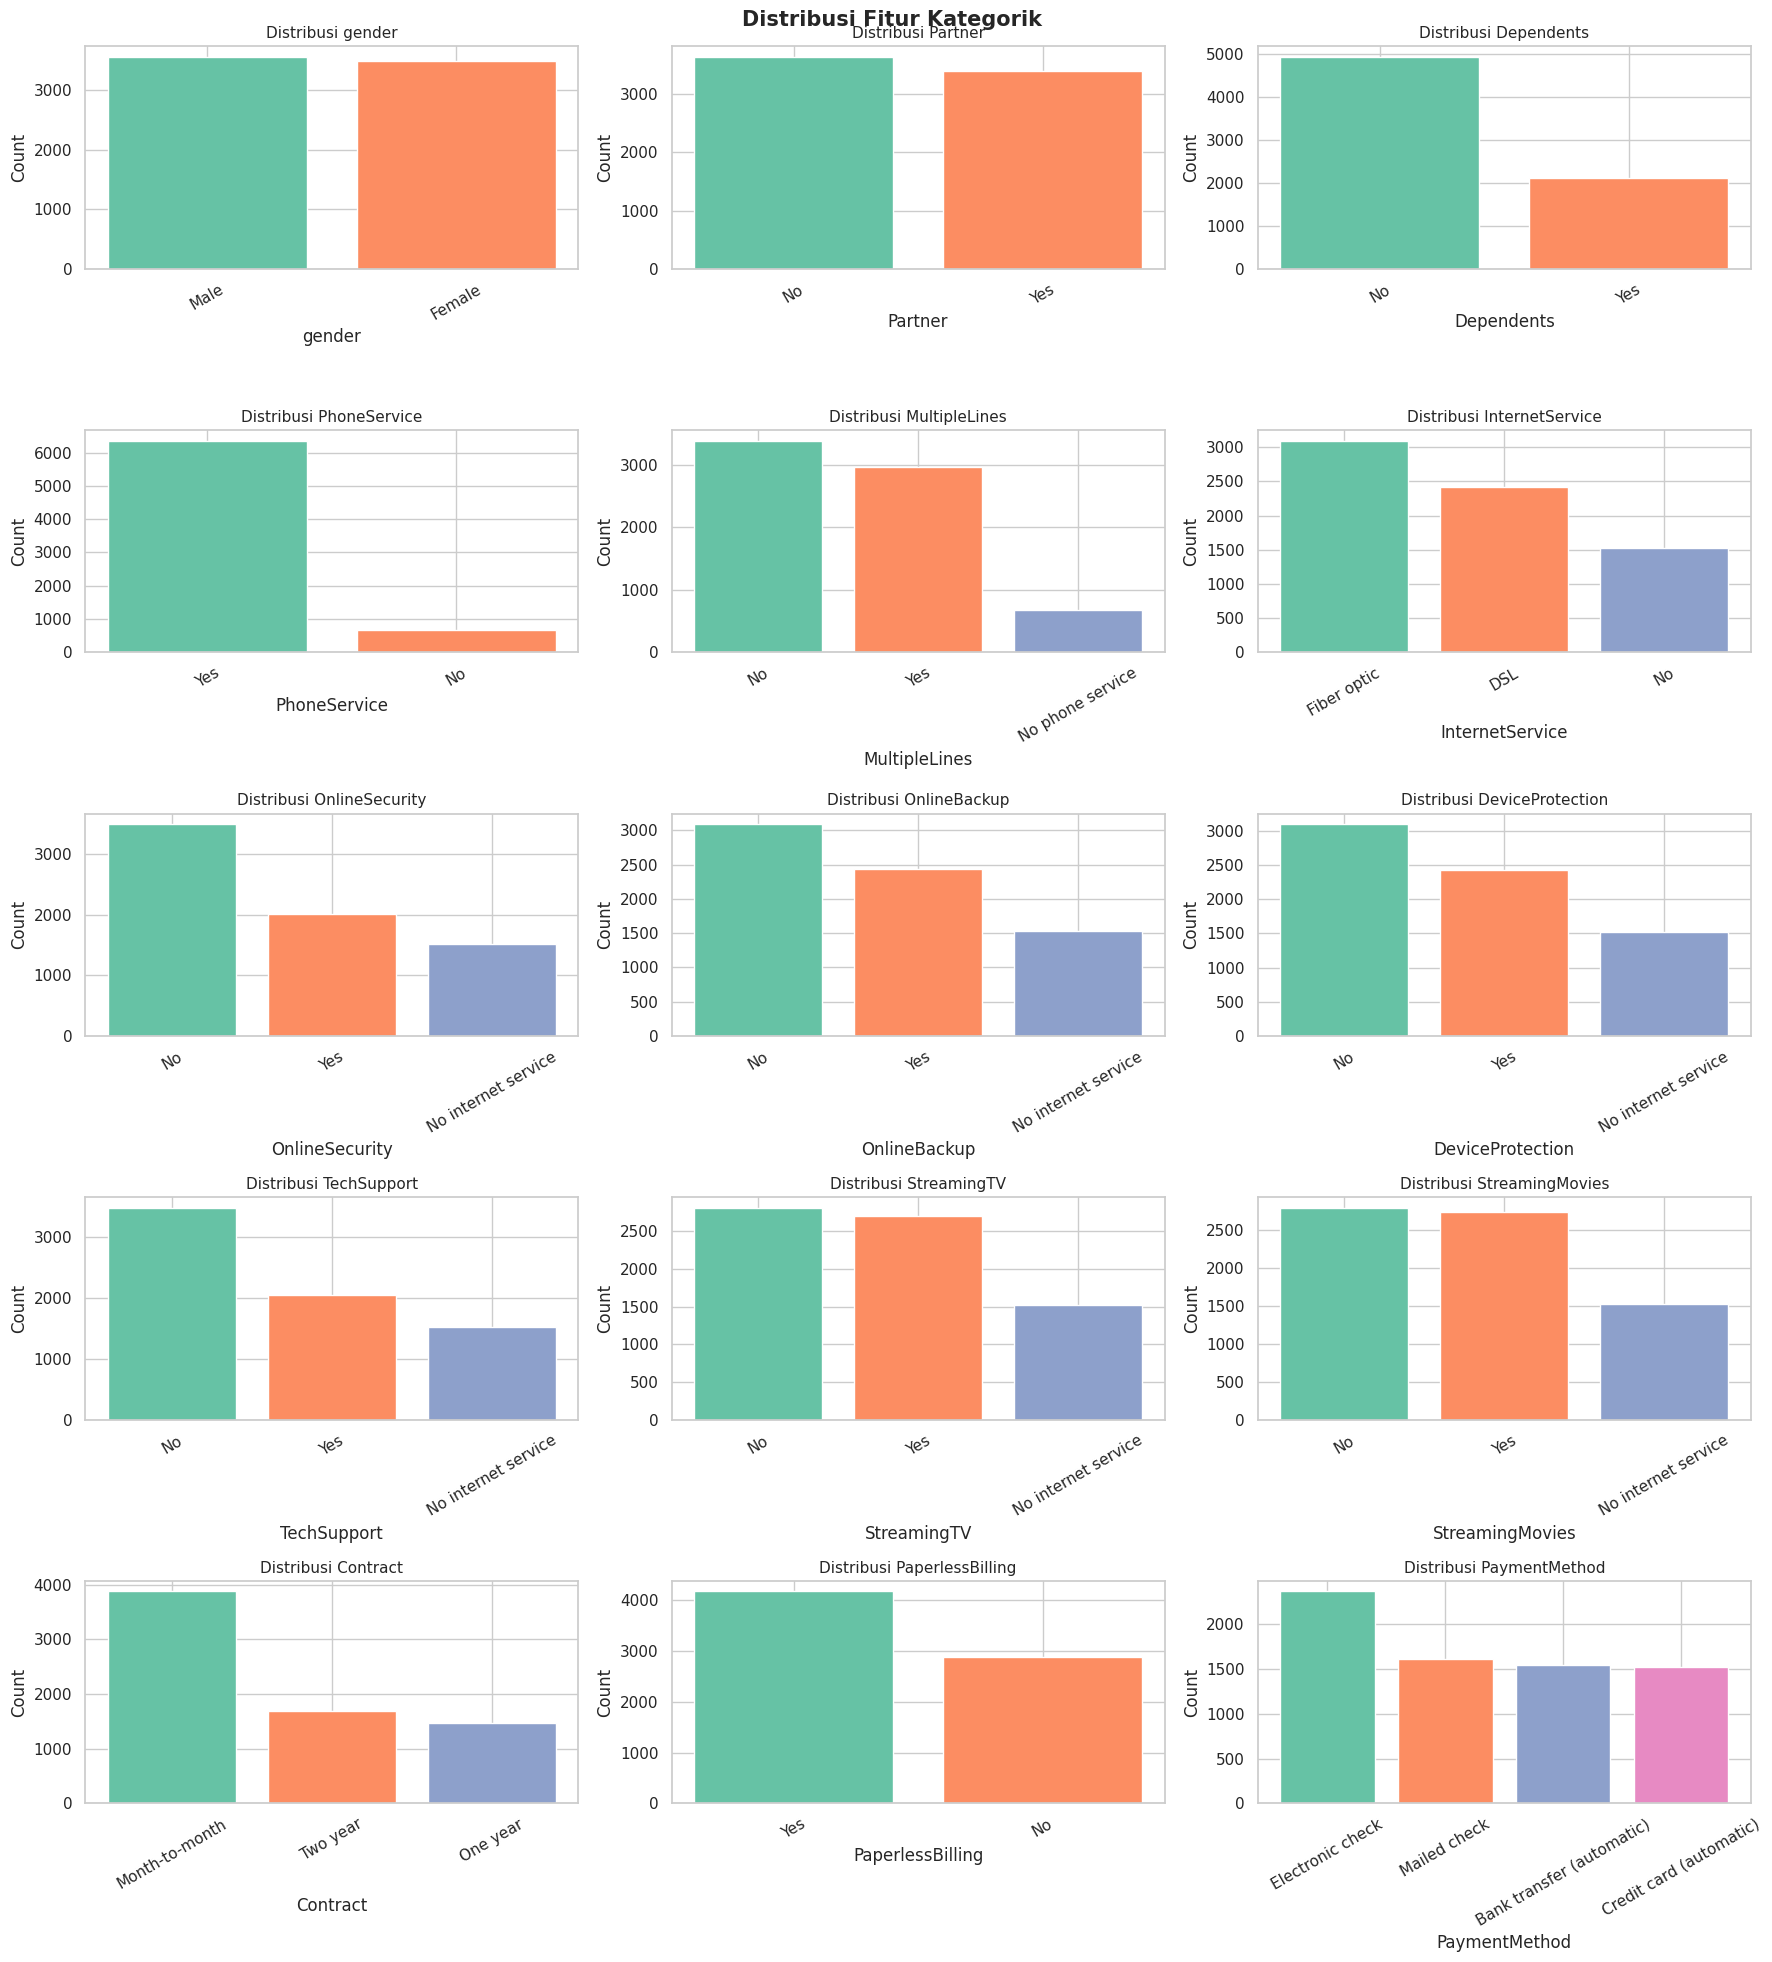

In [14]:
# ============================================================
# 4.4 Distribusi Fitur Kategorik
# ============================================================
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c not in ['customerID', 'Churn']]

n_cols = 3
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    value_counts = df[col].value_counts()
    axes[i].bar(value_counts.index, value_counts.values,
                color=sns.color_palette('Set2', len(value_counts)))
    axes[i].set_title(f'Distribusi {col}', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30)

# Sembunyikan subplot kosong
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Fitur Kategorik', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

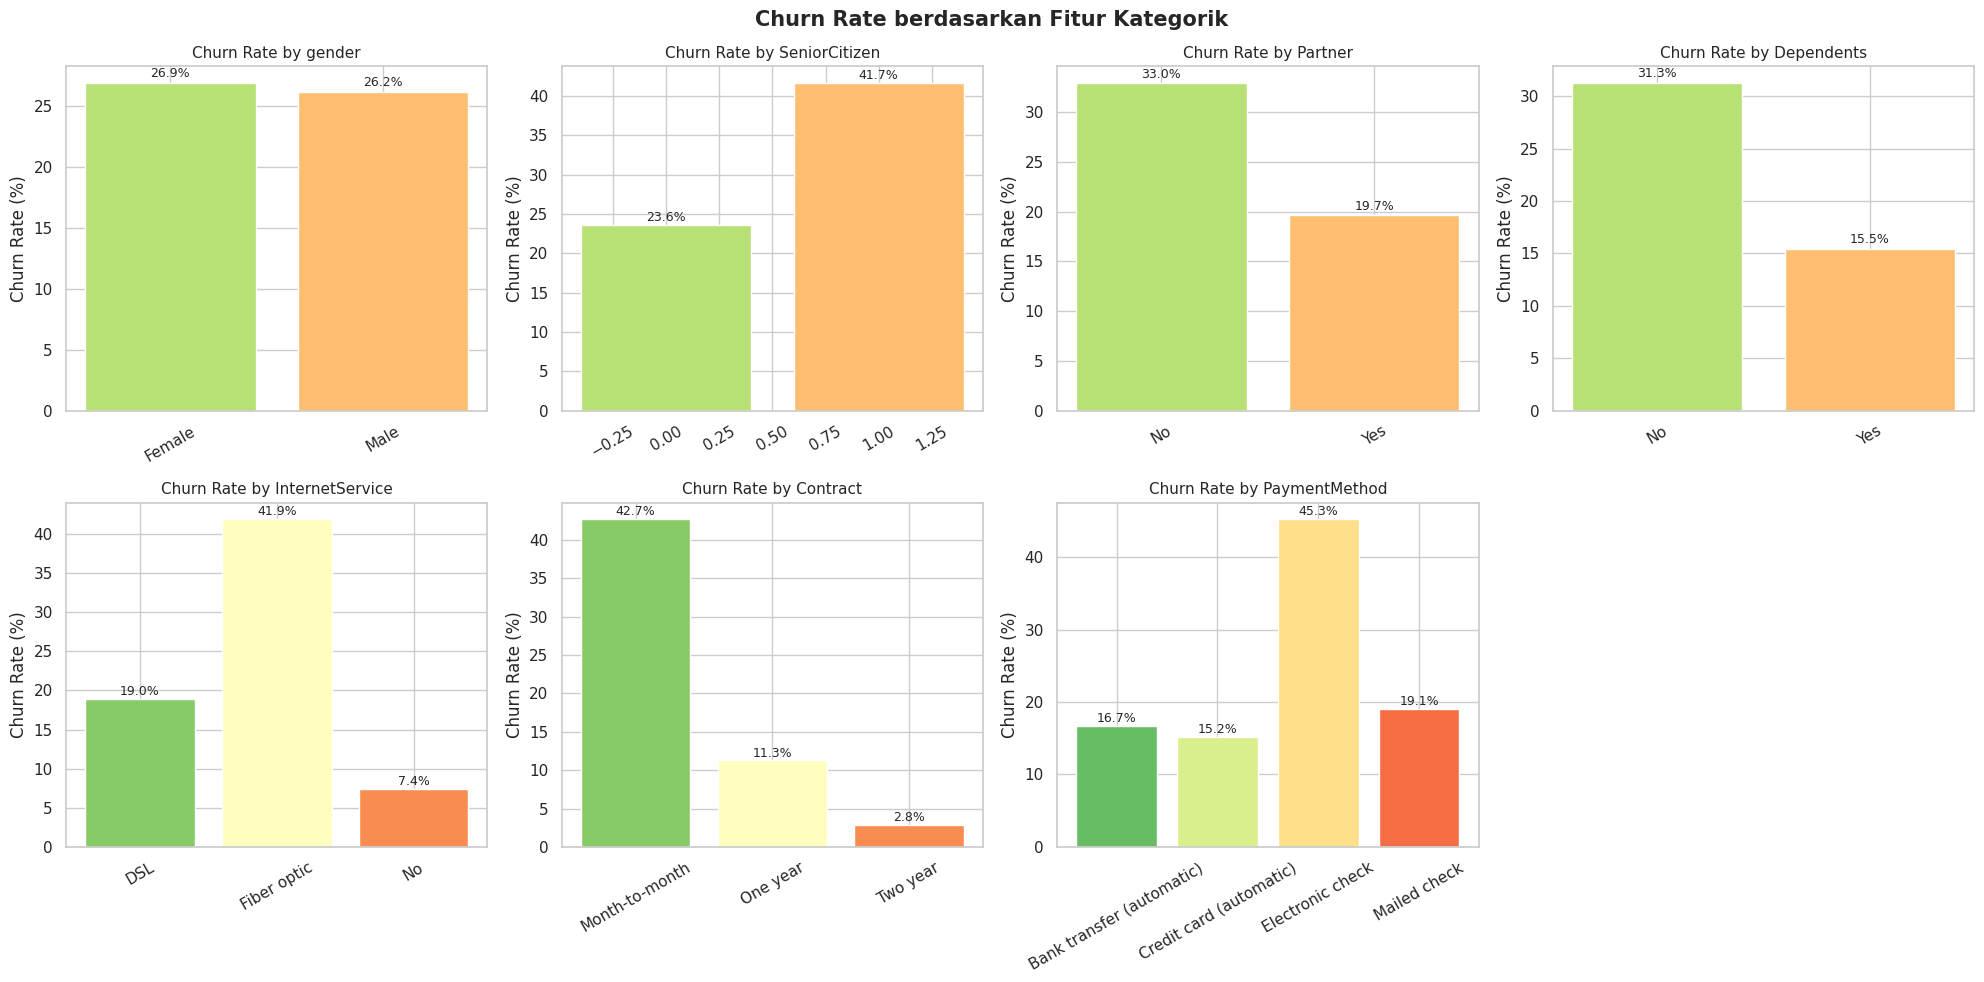

In [15]:
# ============================================================
# 4.5 Hubungan Fitur Kategorik dengan Churn
# ============================================================
key_cat = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
           'InternetService', 'Contract', 'PaymentMethod']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(key_cat):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
    axes[i].bar(churn_rate.index, churn_rate.values,
                color=sns.color_palette('RdYlGn_r', len(churn_rate)))
    axes[i].set_title(f'Churn Rate by {col}', fontsize=11)
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=30)
    for j, (idx, val) in enumerate(churn_rate.items()):
        axes[i].text(j, val + 0.5, f'{val:.1f}%', ha='center', fontsize=9)

axes[-1].set_visible(False)
plt.suptitle('Churn Rate berdasarkan Fitur Kategorik', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

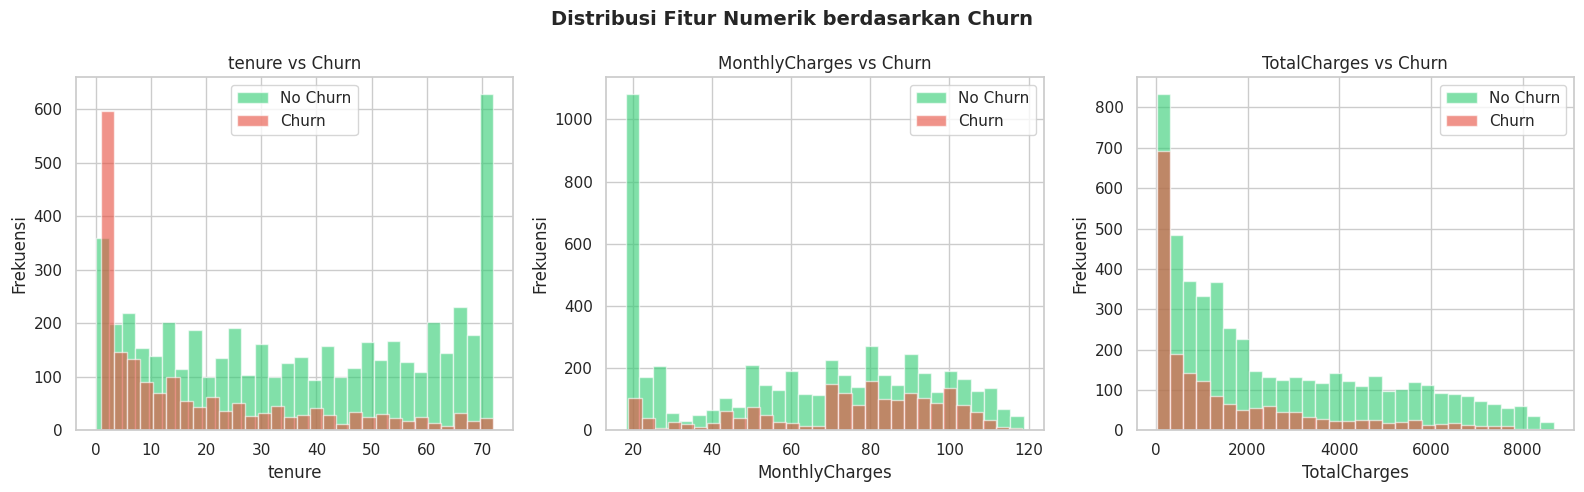

In [16]:
# ============================================================
# 4.5b Hubungan Fitur Numerik dengan Churn
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(num_cols):
    churn_yes = df[df['Churn'] == 'Yes'][col].dropna()
    churn_no  = df[df['Churn'] == 'No'][col].dropna()
    axes[i].hist(churn_no, bins=30, alpha=0.6, label='No Churn', color='#2ecc71', edgecolor='white')
    axes[i].hist(churn_yes, bins=30, alpha=0.6, label='Churn', color='#e74c3c', edgecolor='white')
    axes[i].set_title(f'{col} vs Churn', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')
    axes[i].legend()

plt.suptitle('Distribusi Fitur Numerik berdasarkan Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

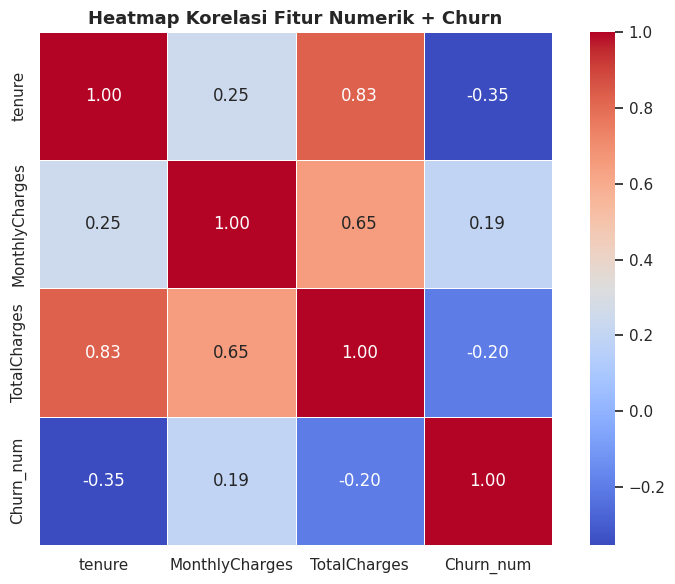

In [17]:
# ============================================================
# 4.5c Correlation Heatmap (Fitur Numerik)
# ============================================================
corr_df = df[num_cols].copy()
corr_df['Churn_num'] = (df['Churn'] == 'Yes').astype(int)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Heatmap Korelasi Fitur Numerik + Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# 4.6 Deteksi Outlier menggunakan IQR
# ============================================================
print('=== Deteksi Outlier (IQR Method) ===')
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f'{col}: {n_outliers} outlier(s) | Batas bawah: {lower:.2f} | Batas atas: {upper:.2f}')

=== Deteksi Outlier (IQR Method) ===
tenure: 0 outlier(s) | Batas bawah: -60.00 | Batas atas: 124.00
MonthlyCharges: 0 outlier(s) | Batas bawah: -46.02 | Batas atas: 171.38
TotalCharges: 0 outlier(s) | Batas bawah: -4688.48 | Batas atas: 8884.67


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [19]:
# ============================================================
# 5.1 Penanganan Missing Values
# ============================================================
df_clean = df.copy()

# Hapus kolom customerID (tidak berguna untuk model)
df_clean.drop(columns=['customerID'], inplace=True)
print('✅ Kolom customerID dihapus')

# Konversi TotalCharges ke numerik (nilai ' ' akan menjadi NaN)
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
print(f'   Missing values di TotalCharges setelah konversi: {df_clean["TotalCharges"].isnull().sum()}')

# Imputasi TotalCharges dengan median
median_tc = df_clean['TotalCharges'].median()
df_clean['TotalCharges'].fillna(median_tc, inplace=True)
print(f'✅ TotalCharges diimputasi dengan median: {median_tc:.2f}')

# Cek ulang missing values
print(f'\nTotal missing values setelah penanganan: {df_clean.isnull().sum().sum()}')

✅ Kolom customerID dihapus
   Missing values di TotalCharges setelah konversi: 11
✅ TotalCharges diimputasi dengan median: 1397.47

Total missing values setelah penanganan: 0


In [20]:
# ============================================================
# 5.2 Encoding Variabel Kategorik
# ============================================================

# Label Encoding untuk kolom biner (2 nilai unik)
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'Churn']

le = LabelEncoder()
for col in binary_cols:
    df_clean[col] = le.fit_transform(df_clean[col])
    print(f'✅ Label Encoding: {col}')

print()

# One-Hot Encoding untuk kolom multi-kategori
multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
              'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
              'Contract', 'PaymentMethod']

df_clean = pd.get_dummies(df_clean, columns=multi_cols, drop_first=False)
print(f'✅ One-Hot Encoding diterapkan pada {len(multi_cols)} kolom')
print(f'   Jumlah kolom setelah encoding: {df_clean.shape[1]}')

✅ Label Encoding: gender
✅ Label Encoding: Partner
✅ Label Encoding: Dependents
✅ Label Encoding: PhoneService
✅ Label Encoding: PaperlessBilling
✅ Label Encoding: Churn

✅ One-Hot Encoding diterapkan pada 10 kolom
   Jumlah kolom setelah encoding: 41


In [21]:
# ============================================================
# 5.3 Feature Scaling (StandardScaler)
# ============================================================
scale_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()
df_clean[scale_cols] = scaler.fit_transform(df_clean[scale_cols])

print('✅ StandardScaler diterapkan pada kolom numerik:')
for col in scale_cols:
    print(f'   {col}: mean={df_clean[col].mean():.4f}, std={df_clean[col].std():.4f}')

✅ StandardScaler diterapkan pada kolom numerik:
   tenure: mean=-0.0000, std=1.0001
   MonthlyCharges: mean=-0.0000, std=1.0001
   TotalCharges: mean=-0.0000, std=1.0001


In [22]:
# ============================================================
# 5.4 Train-Test Split
# ============================================================
X = df_clean.drop(columns=['Churn'])
y = df_clean['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('✅ Data berhasil dibagi:')
print(f'   Training set  : {X_train.shape[0]} sampel ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'   Testing set   : {X_test.shape[0]} sampel ({X_test.shape[0]/len(X)*100:.1f}%)')
print(f'   Jumlah fitur  : {X_train.shape[1]}')
print(f'\nDistribusi Churn di Train: {y_train.value_counts(normalize=True).round(3).to_dict()}')
print(f'Distribusi Churn di Test : {y_test.value_counts(normalize=True).round(3).to_dict()}')

✅ Data berhasil dibagi:
   Training set  : 5634 sampel (80.0%)
   Testing set   : 1409 sampel (20.0%)
   Jumlah fitur  : 40

Distribusi Churn di Train: {0: 0.735, 1: 0.265}
Distribusi Churn di Test : {0: 0.735, 1: 0.265}


In [23]:
# ============================================================
# 5.5 Simpan Dataset Hasil Preprocessing
# ============================================================
import os
os.makedirs('telcocustomerchurn_preprocessing', exist_ok=True)

# Simpan dataset lengkap yang sudah diproses
df_clean.to_csv('telcocustomerchurn_preprocessing/telcocustomerchurn_preprocessing.csv', index=False)

# Simpan train & test set secara terpisah
X_train.to_csv('telcocustomerchurn_preprocessing/X_train.csv', index=False)
X_test.to_csv('telcocustomerchurn_preprocessing/X_test.csv', index=False)
y_train.to_csv('telcocustomerchurn_preprocessing/y_train.csv', index=False)
y_test.to_csv('telcocustomerchurn_preprocessing/y_test.csv', index=False)

print('✅ Semua file berhasil disimpan:')
print('   📁 telcocustomerchurn_preprocessing/')
print('      ├── telcocustomerchurn_preprocessing.csv  (dataset lengkap)')
print('      ├── X_train.csv')
print('      ├── X_test.csv')
print('      ├── y_train.csv')
print('      └── y_test.csv')

✅ Semua file berhasil disimpan:
   📁 telcocustomerchurn_preprocessing/
      ├── telcocustomerchurn_preprocessing.csv  (dataset lengkap)
      ├── X_train.csv
      ├── X_test.csv
      ├── y_train.csv
      └── y_test.csv


In [24]:
# ============================================================
# 5.6 Ringkasan
# ============================================================
print('=' * 55)
print('         RINGKASAN PREPROCESSING SELESAI')
print('=' * 55)
print(f'Dataset asli    : {df.shape[0]} baris x {df.shape[1]} kolom')
print(f'Dataset bersih  : {df_clean.shape[0]} baris x {df_clean.shape[1]} kolom')
print()
print('Langkah-langkah yang dilakukan:')
print('  1. Hapus kolom customerID')
print('  2. Konversi TotalCharges ke numerik')
print('  3. Imputasi missing values (median)')
print('  4. Label Encoding (kolom biner)')
print('  5. One-Hot Encoding (kolom multi-kategori)')
print('  6. StandardScaler (fitur numerik)')
print('  7. Train-Test Split (80:20, stratified)')
print('=' * 55)

         RINGKASAN PREPROCESSING SELESAI
Dataset asli    : 7043 baris x 21 kolom
Dataset bersih  : 7043 baris x 41 kolom

Langkah-langkah yang dilakukan:
  1. Hapus kolom customerID
  2. Konversi TotalCharges ke numerik
  3. Imputasi missing values (median)
  4. Label Encoding (kolom biner)
  5. One-Hot Encoding (kolom multi-kategori)
  6. StandardScaler (fitur numerik)
  7. Train-Test Split (80:20, stratified)
